<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>


# Bagging with Non-Tree Models
#### Suatcan Isikdogan
#### Hildebrand Department of Petroleum and Geosystems Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin


## Executive Summary

Bagging is widely used with tree-based models, but its effects on non-tree models are less commonly explored. In this project, we apply bagging to two models:

* Linear Regression
* K-Nearest Neighbors (K-NN)

to evaluate how their performance changes. The results show that bagging provides meaningful variance reduction for the K-NN model, while Linear Regression, being inherently low-variance, exhibits little to no improvement. This highlights how the effectiveness of bagging depends strongly on the underlying model characteristics.

## Import Packages

In [1]:

# Numerical and data handling
import numpy as np               # Efficient numerical operations and arrays
import pandas as pd              # Loading, cleaning, and manipulating tabular data

# Machine learning models
from sklearn.neighbors import KNeighborsRegressor   # K-NN regression model
from sklearn.linear_model import LinearRegression    # Linear regression baseline model
from sklearn.ensemble import BaggingRegressor        # Bagging ensemble method for variance reduction

# Model evaluation and data splitting
from sklearn.model_selection import train_test_split # Split data into training and test sets
from sklearn.metrics import mean_squared_error, r2_score  # Regression performance metrics

# Visualization
import matplotlib.pyplot as plt   # Static plots and figures
import plotly.express as px       # Interactive visualizations

# Interactive widgets
import ipywidgets as widgets       # Interactive controls (sliders, dropdowns)
from ipywidgets import interact    # Easy function-based interactive UI

# Jupyter display utilities
from IPython.display import display  # Display dataframes, widgets, outputs in notebook



## Load Data
This workflow utilizes the synthetic dataset unconv_MV_v3.csv, from Professor Michael Pyrcz (@GeostatsGuy), GeoDataSets from [GeostatsGuy GitHub] https://github.com/GeostatsGuy/GeoDataSets.


The dataset includes:

- `Well` – well identifier (categorical index, removed from modeling)
- `Por` – porosity
- `LogPerm` – log10(permeability)
- `AI` – acoustic impedance
- `Brittle` – brittleness index
- `TOC` – total organic carbon
- `VR` – vitrinite reflectance
- `Prod` – production (target variable in this workflow)


In [2]:

data_url = "https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV_v3.csv"
my_data = pd.read_csv(data_url)

print("Data loaded successfully from:")
print(data_url)

print("\nFirst 5 rows:")
display(my_data.head())

print("\nColumn names:")
print(list(my_data.columns))

print("\nData shape (rows, columns):")
print(my_data.shape)


Data loaded successfully from:
https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV_v3.csv

First 5 rows:


,Well,Por,LogPerm,AI,Brittle,TOC,VR,Prod
0,1,12.08,1.07,2.80,81.40,1.16,2.31,1695.360819
1,2,12.38,1.26,3.22,46.17,0.89,1.88,3007.096063
2,3,14.02,0.95,4.01,72.80,0.89,2.72,2531.938259
3,4,17.67,1.91,2.63,39.81,1.08,1.88,5288.514854
4,5,17.52,1.52,3.18,10.94,1.51,1.90,2859.469624



Column names:
['Well', 'Por', 'LogPerm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod']

Data shape (rows, columns):
(200, 8)


### Minor Changes Regarding the Dataset

Minor data adjustments were applied to improve modeling consistency, including column renaming and selected scaling/formatting changes. These operations ensure that all variables remain numerically consistent with standard subsurface machine-learning workflows.

In [3]:
# Remove the Well identifier column if present
if "Well" in my_data.columns:
    my_data = my_data.drop(columns=["Well"])

Moreover, the column name "Prod" will be changed as "Production".

In [4]:
# Rename Prod to Production
my_data = my_data.rename(columns={"Prod": "Production"})

print("Updated column names:")
print(list(my_data.columns))


Updated column names:
['Por', 'LogPerm', 'AI', 'Brittle', 'TOC', 'VR', 'Production']


### Adding Random Noise

To explore model sensitivity, controlled Gaussian noise was optionally added to selected predictors. This allows testing how bagging responds to increased data variance—especially relevant for K-NN. Adding noise increases randomness in local neighborhoods, helping highlight variance-reduction benefits.
Noise addition was kept moderate to preserve underlying geological trends.

In [5]:
# Set reproducibility
rng = np.random.default_rng(42)

# Store original production for comparison
if "Prod_clean" not in my_data.columns:
    my_data["Prod_clean"] = my_data["Production"]

# Choose noise level (adjust if needed)
noise_std = my_data["Production"].std() * 0.15   # 15% of production standard deviation

# Generate Gaussian noise
noise = rng.normal(loc=0, scale=noise_std, size=len(my_data))

# Add noise to production
my_data["Production"] = my_data["Prod_clean"] + noise

print("Random noise added to 'Production' to increase variance.")
print(f"Noise standard deviation: {noise_std:.2f}")

display(my_data[["Prod_clean", "Production"]].head())


Random noise added to 'Production' to increase variance.
Noise standard deviation: 232.99


,Prod_clean,Production
0,1695.360819,1766.357349
1,3007.096063,2764.788467
2,2531.938259,2706.787109
3,5288.514854,5507.658564
4,2859.469624,2404.894748


## Summary Statistics for Tabular Data

Before training our linear regression and K-NN models, let's look at the summary statistics of our dataset.

In [6]:

# Summary statistics
print("Summary statistics:")
display(my_data.describe().T)


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Por,200.0,14.991150,2.971176,6.550000,12.912500,15.070000,17.402500,23.550000
LogPerm,200.0,1.386000,0.407856,0.120000,1.137500,1.395000,1.665000,2.290000
AI,200.0,2.968850,0.566885,1.280000,2.547500,2.955000,3.345000,4.630000
Brittle,200.0,48.161950,14.129455,10.940000,37.755000,49.510000,58.262500,84.330000
TOC,200.0,0.990450,0.481588,-0.190000,0.617500,1.030000,1.350000,2.180000
VR,200.0,1.964300,0.300827,0.930000,1.770000,1.960000,2.142500,2.870000
Production,200.0,3857.312317,1551.283050,797.995588,2627.596911,3683.493766,4717.224612,8552.303216
Prod_clean,200.0,3864.407081,1553.277558,839.822063,2686.227611,3604.303506,4752.637555,8590.384044


### Data Visualization

Furthermore, it's important to visualize the data we're dealing with, so we can have a better understanding of each feature.

Firstly, let's plot the histograms of our features.

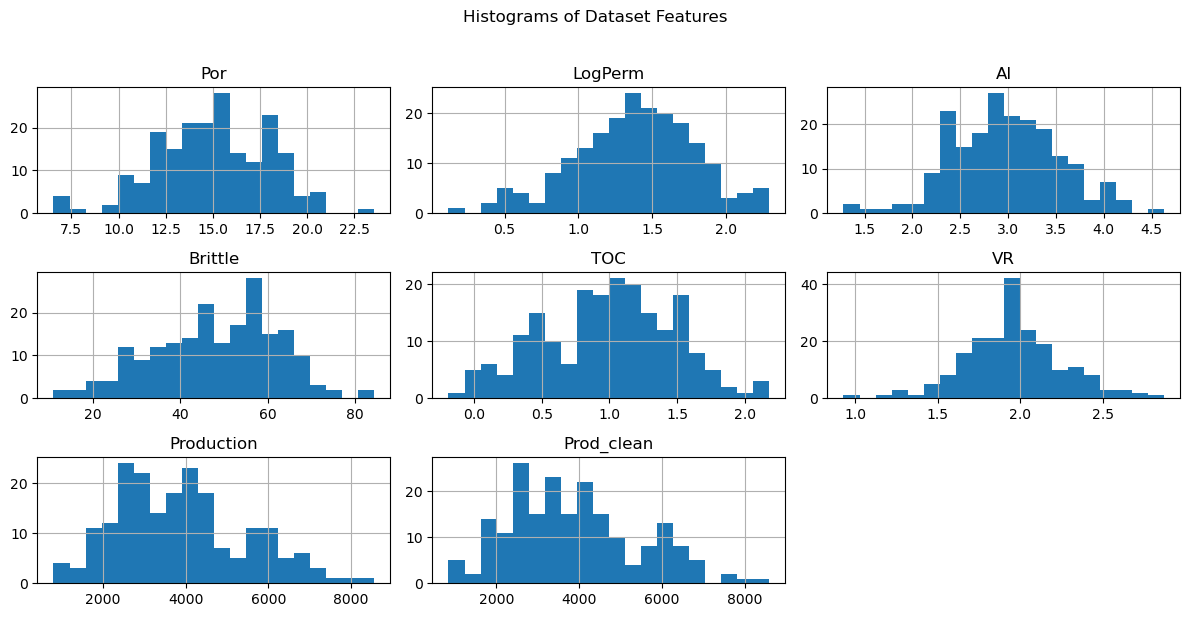

In [7]:

# Histograms of all variables
my_data.hist(bins=20, figsize=(12, 6))
plt.suptitle("Histograms of Dataset Features", y=1.02)
plt.tight_layout()
plt.show()


Histogram of production to observe skewness.

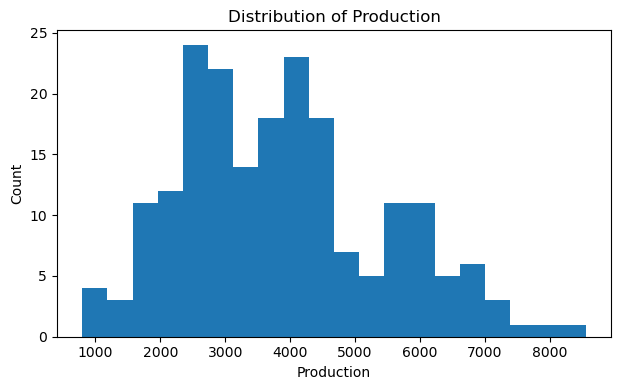

In [8]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(my_data["Production"], bins=20)
plt.xlabel("Production")
plt.ylabel("Count")
plt.title("Distribution of Production")
plt.tight_layout()
plt.show()


Next, the correlation matrix was plotted to properly understand the relationship between the features.

The matrix below indicates that porosity, LogPerm, and TOC features are the most important features correlated with production.

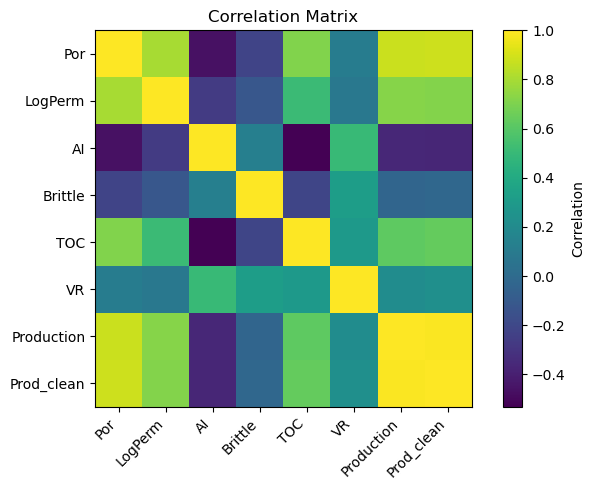

In [9]:
# Correlation matrix
corr = my_data.corr(numeric_only=True)

plt.figure(figsize=(7, 5))
im = plt.imshow(corr, cmap="viridis", interpolation="nearest")
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Lastly, by plotting crossplots of each feature vs. production, we can finalize the data visualization section and begin training our base models.

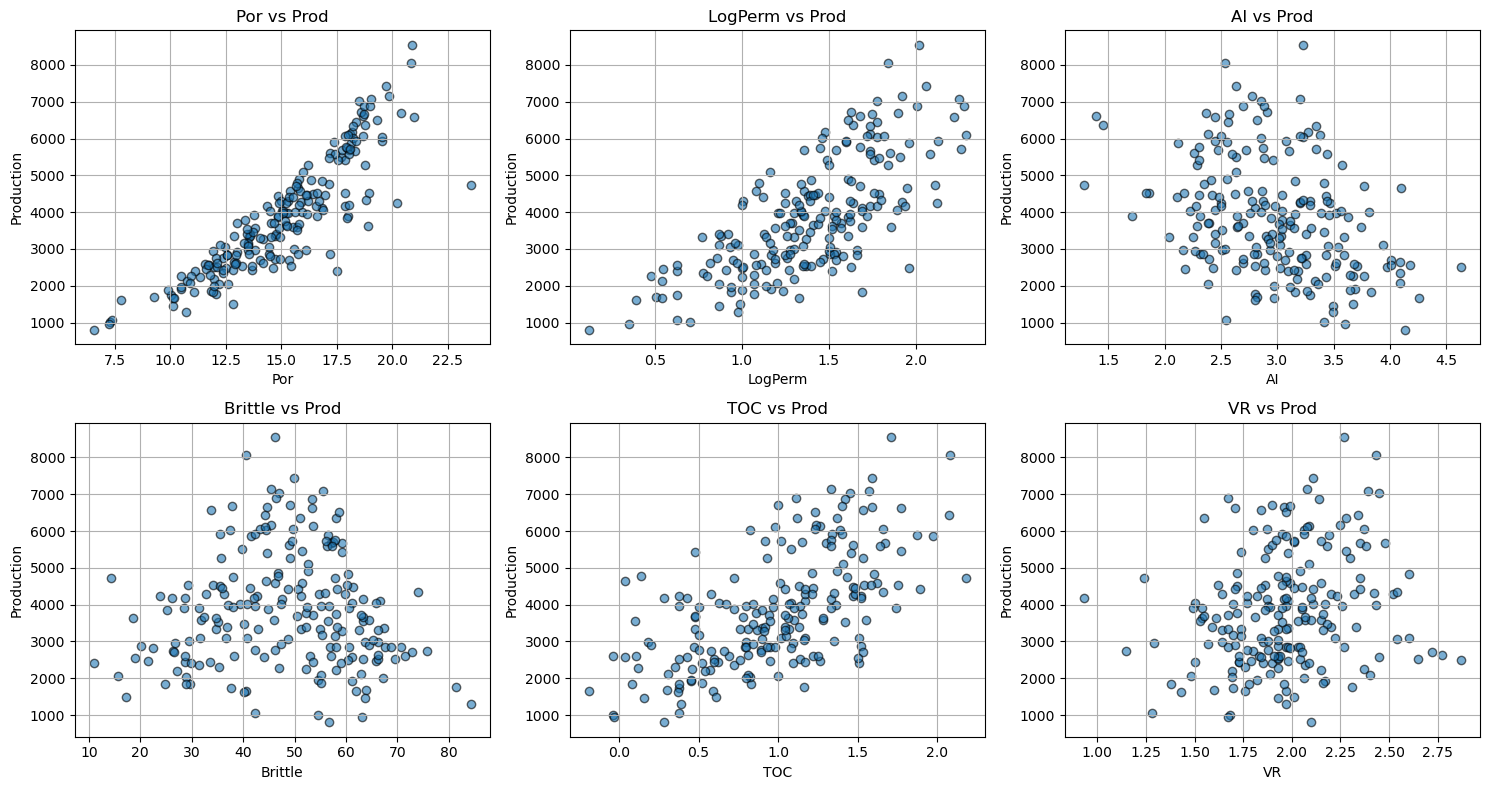

In [10]:

# Crossplots of features vs Prod
features = ["Por", "LogPerm", "AI", "Brittle", "TOC", "VR"]

plt.figure(figsize=(15, 8))
for i, feat in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(my_data[feat], my_data["Production"], alpha=0.6, edgecolors="black")
    plt.xlabel(feat)
    plt.ylabel("Production")
    plt.grid(True)
    plt.title(f"{feat} vs Prod")
plt.tight_layout()
plt.show()


## Train/Test Split


We use the following feature set:

- `Por`, `LogPerm`, `AI`, `Brittle`, `TOC`, `VR` as predictors  
- `Prod` as the regression target  

A standard 70/30 train–test split is used to estimate generalization error.


In [11]:
# Feature matrix and target vector
X = my_data[["Por", "LogPerm", "AI", "Brittle", "TOC", "VR"]]
y = my_data["Production"]

# 70/30 train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42     #Test Split Ratio is 0.3 
)

print("Train/Test split completed.")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Train/Test split completed.
Training samples: 140
Testing samples:  60


# Base Models: K-Nearest Neighbors and Linear Regression


We first construct two baseline regression models:

1. **K-Nearest Neighbors (K-NN)** – a non-parametric, higher-variance model.  
2. **Linear Regression** – a simple parametric model with relatively low variance.

These base models serve as a reference for evaluating the benefits of bagging.


## K-Nearest Neighbours Base Model
We build a baseline K-Nearest Neighbors (k = 5) regression model.
K-NN predicts each test sample by averaging the target values of its 5 closest neighbors.
We report the model’s MSE and R² scores, and plot Measured vs. Predicted values to assess how well K-NN captures production trends

K-NN (k=5) Test MSE: 269834.8058
K-NN (k=5) Test R^2: 0.8778


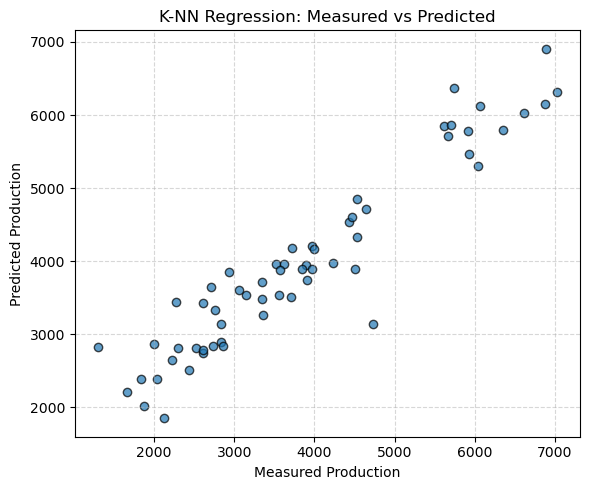

In [12]:
# Base K-NN (k=5)
knn5 = KNeighborsRegressor(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred_knn5 = knn5.predict(X_test)

mse_knn_5 = mean_squared_error(y_test, y_pred_knn5)
r2_knn_5 = r2_score(y_test, y_pred_knn5)


print(f"K-NN (k=5) Test MSE: {mse_knn_5:.4f}")
print(f"K-NN (k=5) Test R^2: {r2_knn_5:.4f}")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_knn5, alpha=0.7, edgecolors="black")
plt.xlabel("Measured Production")
plt.ylabel("Predicted Production")
plt.title("K-NN Regression: Measured vs Predicted")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()



## Linear Regression Base Model
Secondly, let's fit a baseline linear regression model to capture the straight-line relationship between the predictors and production.
The model estimates coefficients for each feature and predicts production using a linear equation.
We evaluate its performance using MSE and R², and visualize results with a Measured vs. Predicted plot.

Linear Regression Test MSE: 398074.3221
Linear Regression Test R^2: 0.8197


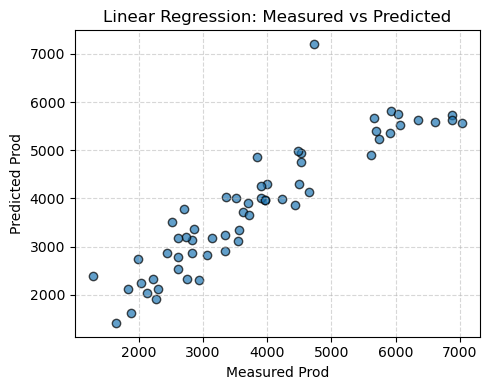

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Test MSE: {mse_lr:.4f}")
print(f"Linear Regression Test R^2: {r2_lr:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred_lr, alpha=0.7, edgecolors="black")
plt.xlabel("Measured Prod")
plt.ylabel("Predicted Prod")
plt.title("Linear Regression: Measured vs Predicted")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

So far, the base case models were built without applying bagging.
The table below provides a brief performance comparison of the baseline K-NN and Linear Regression models.


In [14]:
results_table = pd.DataFrame({
    "Model": ["K-NN (k=5)", "Linear Regression"],
    "MSE": [mse_knn_5, mse_lr],
    "R²": [r2_knn_5, r2_lr]
})

print("\nBase Model Performance Comparison")
display(results_table.round(4))


Base Model Performance Comparison


,Model,MSE,R²
0,K-NN (k=5),269834.8058,0.8778
1,Linear Regression,398074.3221,0.8197


# Bagging with K-NN and Linear Regression


Bagging (Bootstrap Aggregating) reduces variance by training many base learners on bootstrap samples of the data 
and averaging their predictions. Here we compare:

- Bagged K-NN  
- Bagged Linear Regression  

This allows us to investigate how bagging affects a high-variance model (K-NN) versus a low-variance model (Linear Regression).


## Bagged K-NN
In this step, we apply bagging to the K-NN model to reduce variance and improve prediction stability.
Multiple K-NN models are trained on randomly sampled subsets of the data, and their predictions are averaged.
We evaluate the bagged model using MSE and R², and plot the Measured vs. Predicted values to assess performance improvements over the base K-NN model.


Bagged K-NN Test MSE: 278676.7921
Bagged K-NN Test R^2: 0.8738


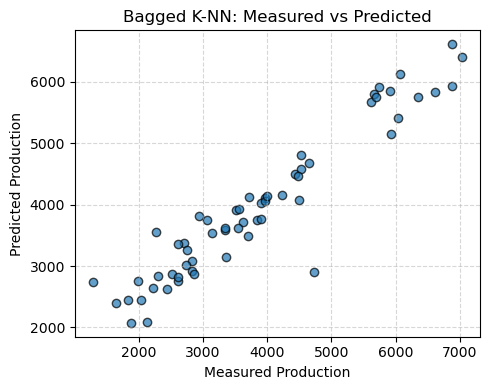

In [15]:
# Bagged K-NN (k=5)
bag_knn5 = BaggingRegressor(
    estimator=KNeighborsRegressor(n_neighbors=5),
    n_estimators=50,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)
bag_knn5.fit(X_train, y_train)
y_pred_bag_knn5 = bag_knn5.predict(X_test)

mse_bag_knn_5 = mean_squared_error(y_test, y_pred_bag_knn5)
r2_bag_knn_5 = r2_score(y_test, y_pred_bag_knn5)

print(f"Bagged K-NN Test MSE: {mse_bag_knn_5:.4f}")
print(f"Bagged K-NN Test R^2: {r2_bag_knn_5:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred_bag_knn5, alpha=0.7, edgecolors="black")
plt.xlabel("Measured Production")
plt.ylabel("Predicted Production")
plt.title("Bagged K-NN: Measured vs Predicted")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()



## Bagged Linear Regression
Now,  the next step is to apply bagging to the Linear Regression model to reduce variance and improve prediction stability.
Multiple linear models are trained on different bootstrapped subsets of the data, and their predictions are averaged.
We evaluate the bagged model using MSE and R², and plot Measured vs. Predicted values to compare performance with the base Linear Regression model.


Bagged Linear Regression Test MSE: 406192.8640
Bagged Linear Regression Test R^2: 0.8161


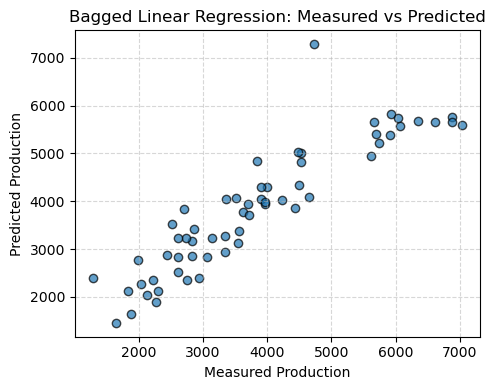

In [16]:
bag_lr = BaggingRegressor(
    estimator=LinearRegression(),
    n_estimators=50,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

bag_lr.fit(X_train, y_train)
y_pred_bag_lr = bag_lr.predict(X_test)

mse_bag_lr = mean_squared_error(y_test, y_pred_bag_lr)
r2_bag_lr = r2_score(y_test, y_pred_bag_lr)

print(f"Bagged Linear Regression Test MSE: {mse_bag_lr:.4f}")
print(f"Bagged Linear Regression Test R^2: {r2_bag_lr:.4f}")

plt.figure(figsize=(5, 4))
plt.scatter(y_test, y_pred_bag_lr, alpha=0.7, edgecolors="black")
plt.xlabel("Measured Production")
plt.ylabel("Predicted Production")
plt.title("Bagged Linear Regression: Measured vs Predicted")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

Now, we can compare the results of bagged and base case scenarios of our model

In [17]:
# Create comparison DataFrame
bag_results = pd.DataFrame({
    "Model": [
        "Base K-NN",
        "Bagged K-NN",
        "Base Linear Reg.",
        "Bagged Linear Reg."
    ],
    "MSE": [
        mse_knn_5, 
        mse_bag_knn_5, 
        mse_lr, 
        mse_bag_lr
    ],
    "R²": [
        r2_knn_5, 
        r2_bag_knn_5, 
        r2_lr, 
        r2_bag_lr
    ]
})

print("\nModel Performance Comparison with Bagging")
display(bag_results.round(4))




Model Performance Comparison with Bagging


,Model,MSE,R²
0,Base K-NN,269834.8058,0.8778
1,Bagged K-NN,278676.7921,0.8738
2,Base Linear Reg.,398074.3221,0.8197
3,Bagged Linear Reg.,406192.8640,0.8161


The results indicate that bagging did not lead to a meaningful performance improvement for either the Linear Regression or the K-NN model. Since Linear regression is a low-variance model, this result is what we expected to observe. However, for k-NN, we expected to see a relatively effective improvement in the MSE and R².

Hence, let's train our k-NN model with a different hyperparameter (with a lower k value to increase variance), and apply bagging to see whether it causes a change in the new model or not.

## Bagged k-NN with Lower Number of Neighbors Value

This time, let's use the hyperparameter k=1 to train our base model, and then apply bagging to see how it works with the updated model.

K-NN (k=1) Test MSE: 220693.8848
K-NN (k=1) Test R^2: 0.9001
Bagged K-NN (k=1) Test MSE: 173576.3100
Bagged K-NN (k=1) Test R^2: 0.9214


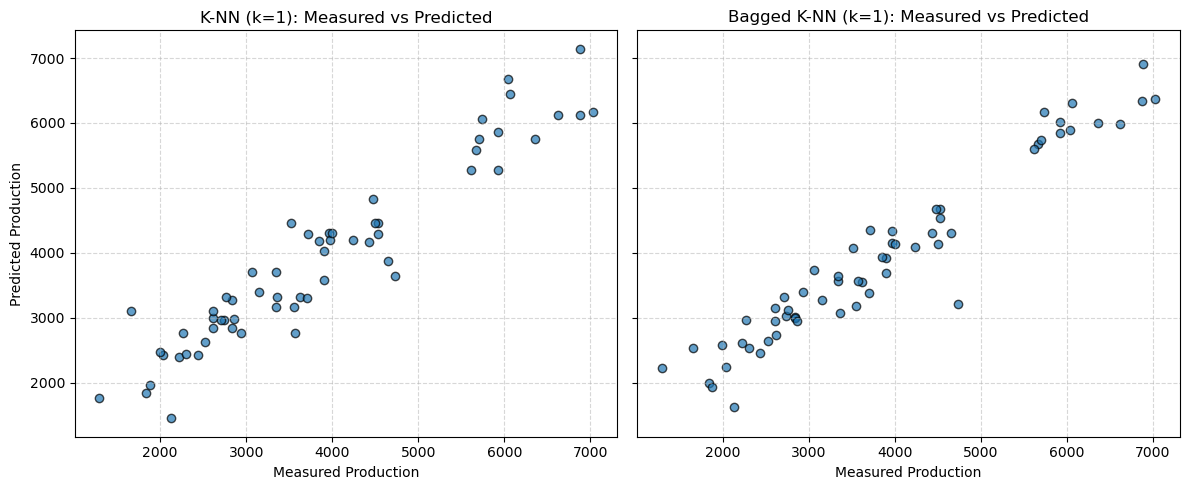

In [18]:
# Base K-NN (k=1)
knn1 = KNeighborsRegressor(n_neighbors=1)
knn1.fit(X_train, y_train)
y_pred_knn1 = knn1.predict(X_test)

mse_knn_1 = mean_squared_error(y_test, y_pred_knn1)
r2_knn_1  = r2_score(y_test, y_pred_knn1)

print(f"K-NN (k=1) Test MSE: {mse_knn_1:.4f}")
print(f"K-NN (k=1) Test R^2: {r2_knn_1:.4f}")

# Bagged K-NN (k=1)
bag_knn1 = BaggingRegressor(
    estimator=KNeighborsRegressor(n_neighbors=1),
    n_estimators=50,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)
bag_knn1.fit(X_train, y_train)
y_pred_bag_knn1 = bag_knn1.predict(X_test)

mse_bag_knn_1 = mean_squared_error(y_test, y_pred_bag_knn1)
r2_bag_knn_1  = r2_score(y_test, y_pred_bag_knn1)

print(f"Bagged K-NN (k=1) Test MSE: {mse_bag_knn_1:.4f}")
print(f"Bagged K-NN (k=1) Test R^2: {r2_bag_knn_1:.4f}")

# Side-by-side plots (same size & axes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Base K-NN (k=1)
axes[0].scatter(y_test, y_pred_knn1, alpha=0.7, edgecolors="black")
axes[0].set_title("K-NN (k=1): Measured vs Predicted")
axes[0].set_xlabel("Measured Production")
axes[0].set_ylabel("Predicted Production")
axes[0].grid(True, ls="--", alpha=0.5)

# Bagged K-NN (k=1)
axes[1].scatter(y_test, y_pred_bag_knn1, alpha=0.7, edgecolors="black")
axes[1].set_title("Bagged K-NN (k=1): Measured vs Predicted")
axes[1].set_xlabel("Measured Production")
axes[1].grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()


As we can with a low k hyperparameter, which increases the variance of the model, the bagging improved the model performance of our new k-NN model. In other words, the R2 value is improved from 0.9001 to 0.9214, whereas MSE is 

## Comparison of All Results
Now, it's time to observe the effect of bagging by comparing all the results.

In [19]:
bag_results = pd.DataFrame({
    "Model": [
        "Base K-NN (k=5)",
        "Bagged K-NN (k=5)",
        "Base Linear Reg.",
        "Bagged Linear Reg.",
        "High-Variance K-NN (k=1)",
        "Bagged K-NN (k=1)"
    ],
    "MSE": [
        mse_knn_5, mse_bag_knn_5,
        mse_lr, mse_bag_lr,
        mse_knn_1, mse_bag_knn_1
    ],
    "R²": [
        r2_knn_5, r2_bag_knn_5,
        r2_lr, r2_bag_lr,
        r2_knn_1, r2_bag_knn_1
    ]
})

print("\nModel Performance Comparison with Bagging")
display(bag_results.round(4))



Model Performance Comparison with Bagging


,Model,MSE,R²
0,Base K-NN (k=5),269834.8058,0.8778
1,Bagged K-NN (k=5),278676.7921,0.8738
2,Base Linear Reg.,398074.3221,0.8197
3,Bagged Linear Reg.,406192.8640,0.8161
4,High-Variance K-NN (k=1),220693.8848,0.9001
5,Bagged K-NN (k=1),173576.3100,0.9214


A consolidated table and plot summarize:
* Base Linear Regression
* Bagged Linear Regression
* Base K-NN
* Bagged K-NN (various k values)
  
Key observations:
* Linear Regression: negligible differences
* K-NN: some stabilization, strongest when k is small
* Bagging effects increase with estimator variance
* Dataset noise level limits potential improvement.

These findings are consistent with ensemble theory.

## Interactive K-NN Bagging Dashboard

An interactive dashboard was developed to explore:

* number of neighbors (k)
* number of estimators
* sampling fraction (max_samples)

Users can dynamically observe how these hyperparameters influence predictions, variance, and stability.
This tool provides strong intuition about K-NN’s sensitivity to the bagging application.

In [20]:
#Interactive Bagged K-NN Experiment
def knn_bagging_experiment(k=5, n_estimators=30, max_samples=0.8):
    model = BaggingRegressor(
        estimator=KNeighborsRegressor(n_neighbors=k),
        n_estimators=n_estimators,
        max_samples=max_samples,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    plt.scatter(y_test, y_pred, alpha=0.7, edgecolors="black")
    plt.xlabel("Measured Prod")
    plt.ylabel("Predicted Prod")
    plt.title(f"Bagged K-NN: k={k}, n_estimators={n_estimators}, max_samples={max_samples}\nMSE={mse:.2f}, R^2={r2:.2f}")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

interact(
    knn_bagging_experiment,
    k=widgets.IntSlider(min=1, max=25, step=1, value=5, description="k"),
    n_estimators=widgets.IntSlider(min=5, max=100, step=5, value=30, description="n_estimators"),
    max_samples=widgets.FloatSlider(min=0.1, max=1.0, step=0.1, value=0.8, description="max_samples")
)


interactive(children=(IntSlider(value=5, description='k', max=25, min=1), IntSlider(value=30, description='n_e…

<function __main__.knn_bagging_experiment(k=5, n_estimators=30, max_samples=0.8)>

## Conclusions

Bootstrap aggregation is an effective variance-reduction strategy when applied to high-variance estimators. The results of this project confirm that Linear Regression, a low-variance model, exhibits no notable improvement under bagging.

K-Nearest Neighbors, however, shows greater sensitivity to local fluctuations and therefore benefits more from bagging. While performance improvements on this dataset were moderate due to low noise levels, bagging reduced variance and produced smoother predictions—especially for small values of k.

The interactive dashboard further demonstrates how the bias–variance trade-off depends on hyperparameters and data structure.


### As a result of this project:

- Linear Regression showed minimal change under bagging due to inherently low variance.
- K-NN benefited from variance reduction, though improvements were dataset-dependent.
- Bagging effects became more pronounced when model variance was intentionally increased.
- The interactive dashboard effectively visualized bias–variance trade-offs.


## References

- Pyrcz, M.J., 2024, *Applied Machine Learning in Python: A Hands-on Guide with Code* [e-book]. Zenodo. doi:10.5281/zenodo.15169138  
- Pyrcz, M.J., GeoDataSets GitHub Repository, `unconv_MV_v3.csv`.

#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)